In [4]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

In [5]:
model = joblib.load("../models/solar_model.pkl")

print("Model loaded successfully")

Model loaded successfully


In [6]:
forecast_df = pd.read_csv("../outputs/weather_forecast.csv")

forecast_df["timestamp"] = pd.to_datetime(forecast_df["timestamp"])

forecast_df.head()

,timestamp,temperature,humidity,cloud_cover,wind_speed,precipitation
0,2026-03-10 18:00:00,28.01,25,1,0.40,0
1,2026-03-10 21:00:00,27.59,26,1,1.24,0
2,2026-03-11 00:00:00,25.88,29,0,1.14,0
3,2026-03-11 03:00:00,27.90,30,1,0.89,0
4,2026-03-11 06:00:00,34.17,17,2,3.18,0


In [7]:
forecast_df["hour"] = forecast_df["timestamp"].dt.hour
forecast_df["day_of_week"] = forecast_df["timestamp"].dt.dayofweek
forecast_df["is_weekend"] = forecast_df["day_of_week"].isin([5,6]).astype(int)

forecast_df["sin_hour"] = np.sin(2*np.pi*forecast_df["hour"]/24)
forecast_df["cos_hour"] = np.cos(2*np.pi*forecast_df["hour"]/24)

forecast_df["temp_cloud_interaction"] = (
    forecast_df["temperature"] * (1 - forecast_df["cloud_cover"]/100)
)

In [8]:
forecast_df["rolling_temp"] = forecast_df["temperature"].rolling(3).mean()
forecast_df["lag_solar"] = 0

forecast_df = forecast_df.fillna(0)

In [9]:
features = [
    "temperature",
    "humidity",
    "cloud_cover",
    "wind_speed",
    "precipitation",
    "sin_hour",
    "cos_hour",
    "day_of_week",
    "is_weekend",
    "temp_cloud_interaction",
    "rolling_temp",
    "lag_solar"
]

In [10]:
X_future = forecast_df[features]

predictions = model.predict(X_future)

forecast_df["predicted_solar"] = np.clip(predictions,0,None)

forecast_df.head()

,timestamp,temperature,humidity,cloud_cover,wind_speed,precipitation,hour,day_of_week,is_weekend,sin_hour,cos_hour,temp_cloud_interaction,rolling_temp,lag_solar,predicted_solar
0,2026-03-10 18:00:00,28.01,25,1,0.40,0,18,1,0,-1.000000,-1.836970e-16,27.7299,0.000000,0,10.348133
1,2026-03-10 21:00:00,27.59,26,1,1.24,0,21,1,0,-0.707107,7.071068e-01,27.3141,0.000000,0,10.854349
2,2026-03-11 00:00:00,25.88,29,0,1.14,0,0,2,0,0.000000,1.000000e+00,25.8800,27.160000,0,15.519479
3,2026-03-11 03:00:00,27.90,30,1,0.89,0,3,2,0,0.707107,7.071068e-01,27.6210,27.123333,0,11.838382
4,2026-03-11 06:00:00,34.17,17,2,3.18,0,6,2,0,1.000000,6.123234e-17,33.4866,29.316667,0,8.808738


In [16]:
forecast_df[["timestamp","predicted_solar"]].to_csv(
      "solar_predictions.csv",
    index=False
)

print("Predictions saved")

Predictions saved


In [17]:
history = pd.read_csv("../data/processed_solar_data.csv")

history["timestamp"] = pd.to_datetime(history["timestamp"])

history = history.tail(200)

In [24]:
print(history.head())
print(forecast_df.head())

               timestamp  temperature   humidity  cloud_cover  wind_speed  \
1240 2024-02-21 16:00:00    11.104660  87.922089    42.279204    6.576408   
1241 2024-02-21 17:00:00     9.116970  55.160666    70.929520    4.491048   
1242 2024-02-21 18:00:00     6.936646  70.216248    13.600255    2.899890   
1243 2024-02-21 19:00:00     7.723966  46.520042    24.858000    4.935915   
1244 2024-02-21 20:00:00    11.451042  51.394346    31.923941    4.265526   

      precipitation  solar_output  hour  day_of_week  is_weekend  sin_hour  \
1240            0.0    149.924548    16            2           0 -0.866025   
1241            0.0     41.670293    17            2           0 -0.965926   
1242            0.0     15.190001    18            2           0 -1.000000   
1243            0.0      0.000000    19            2           0 -0.965926   
1244            0.0     12.426935    20            2           0 -0.866025   

          cos_hour  temp_cloud_interaction  rolling_temp   lag_solar

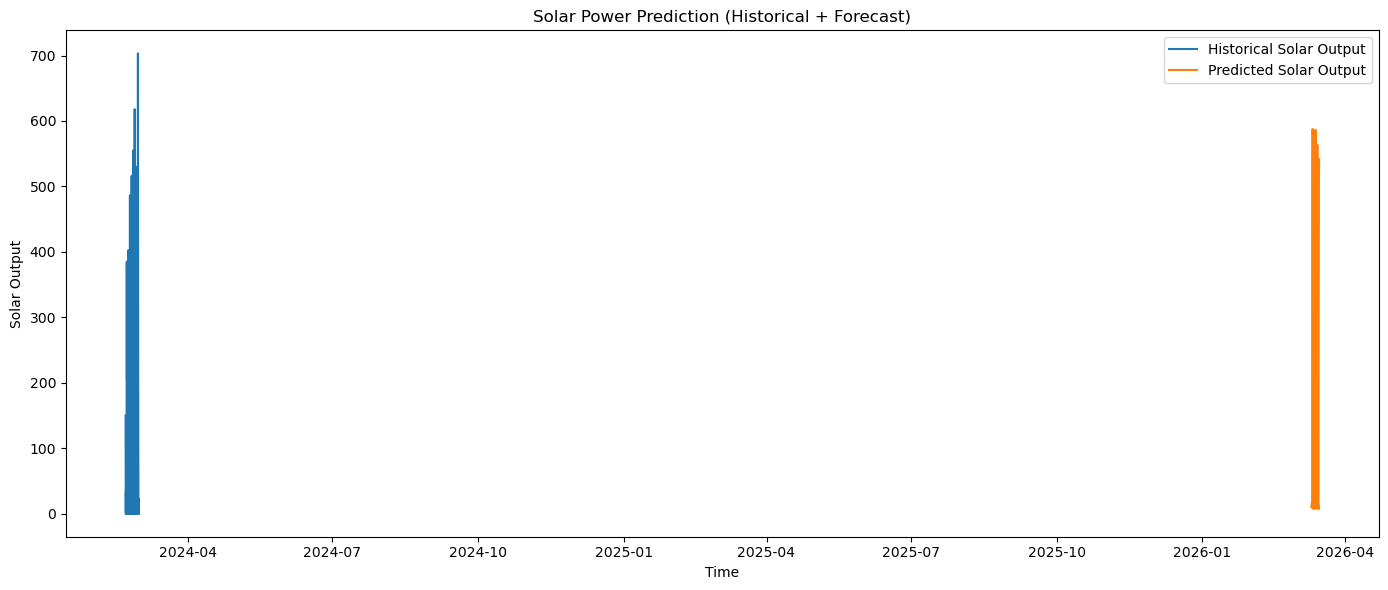

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    history["timestamp"],
    history["solar_output"],
    label="Historical Solar Output",
)

plt.plot(
    forecast_df["timestamp"],
    forecast_df["predicted_solar"],
    label="Predicted Solar Output",
)

plt.xlabel("Time")
plt.ylabel("Solar Output")
plt.title("Solar Power Prediction (Historical + Forecast)")
plt.legend()

plt.tight_layout()

plt.savefig("../outputs/solar_prediction_plot.png", dpi=300)

plt.show()

In [26]:
plt.savefig("../outputs/solar_prediction_plot.png")

<Figure size 640x480 with 0 Axes>

In [23]:

plt.show()